## Kaggle Housing Price Prediction
Notebook for the *Housing Prices Competition for Kaggle Learn Users*

In [116]:
import numpy as np
import pandas as pd

from sklearn.metrics import mean_absolute_error
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split

Columns to investigate:\
'MSSubClass'
'LotArea'
'OverallQual'
'OverallCond'
'YearBuilt'
'YearRemodAdd'
'1stFlrSF'
'2ndFlrSF'
'LowQualFinSF'
'GrLivArea'
'FullBath'
'HalfBath'
'BedroomAbvGr'
'KitchenAbvGr'
'TotRmsAbvGrd'
'Fireplaces'
'WoodDeckSF'
'OpenPorchSF'
'EnclosedPorch'
'3SsnPorch'
'ScreenPorch'
'PoolArea'
'MiscVal'
'MoSold'
'YrSold'

In [15]:
path_house_data = './input/train.csv.gz'
house_data      = pd.read_csv(path_house_data, compression='gzip')

# build some useful features

# combine all bathroom columns to get a total bathroom count 
house_data['TotBath'] = house_data[['BsmtFullBath', 'FullBath']].sum(axis=1) + 0.5 * house_data[['BsmtHalfBath', 'HalfBath']].sum(axis=1)

# format sale year and month into one continuous sale date
house_data['DateSold'] = house_data['YrSold'] + (house_data['MoSold'] - 1) / 12.

In [60]:
house_data[house_data['PoolArea'] > 0]['PoolArea'].count() / house_data['PoolArea'].count()

np.float64(0.004794520547945206)

In [70]:
house_data['OverallCond'].corr(house_data['OverallQual'], method='pearson')

np.float64(-0.09193234263907181)

In [ ]:
# final model features
features = ['LotArea',   # lot area
            'YearBuilt', # year built
            'DateSold',  # sold date, combined year and month
            'TotBath',   # total number of bathrooms
            'MiscVal',   # Miscellaneous value should probably direclty impact the sale price but only in ~50 (3%) of training data so might overfit?
            ]

In [78]:
house_data[house_data['LowQualFinSF'] > 0]['LowQualFinSF'].count()

np.int64(26)

In [ ]:
house_data['NumFlr'] = (house_data['2ndFlrSF'] > 0).astype(int) + 1
house_data['TotSF']  = house_data[['1stFlrSF', '2ndFlrSF', 'LowQualFinSF']].sum(axis=1) # this is just GrLivArea

In [111]:
house_data[['KitchenAbvGr', 'BedroomAbvGr', 'TotBath', 'TotRmsAbvGrd']]

,KitchenAbvGr,BedroomAbvGr,TotBath,TotRmsAbvGrd
0,1,3,3.5,8
1,1,3,2.5,6
2,1,3,3.5,6
3,1,3,2.0,7
4,1,4,3.5,9
...,...,...,...,...
1455,1,3,2.5,7
1456,1,3,3.0,7
1457,1,4,2.0,9
1458,1,2,2.0,5


<Axes: >

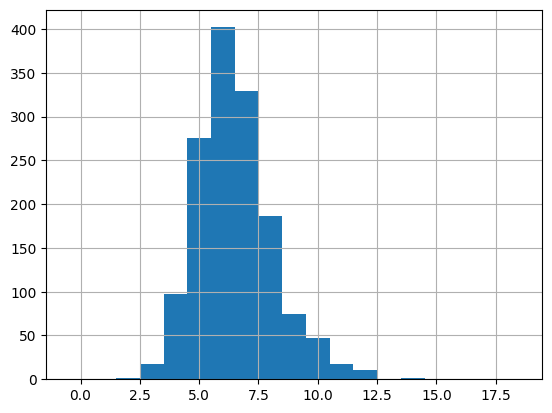

In [123]:
house_data['TotRmsAbvGrd'].hist(bins=np.arange(20) - 0.5)

In [102]:
house_data[house_data['GrLivArea'] > house_data['1stFlrSF'] + house_data['2ndFlrSF']][['1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea']]

,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea
51,816,0,360,1176
88,1013,0,513,1526
125,520,0,234,754
170,854,0,528,1382
185,1518,1518,572,3608
187,808,704,144,1656
197,1360,1360,392,3112
198,929,929,371,2229
263,926,0,390,1316
267,1052,720,420,2192


In [106]:
# features to use in model
features = ['LotArea', 'YearBuilt', 'YrSold', 'NumFlr', 'TotSF', 'FullBath', 'BedroomAbvGr', 'TotRmsAbvGrd', 'TotBath', 'LowQualFinSF']
# features = ['LotArea', 'YearBuilt', 'YrSold', '1stFlrSF', '2ndFlrSF', 'FullBath', 'BedroomAbvGr', 'TotRmsAbvGrd', 'TotBath', 'LowQualFinSF']

# split training data into training and validation
X = house_data[features]
y = house_data['SalePrice']
train_X, val_X, train_y, val_y = train_test_split(X, y, random_state=1234)

In [107]:
# test approach 1, use a random forest regressor
rf_model = RandomForestRegressor(random_state=1234)
rf_model.fit(train_X, train_y)
rf_val_predictions = rf_model.predict(val_X)
rf_val_mae = mean_absolute_error(rf_val_predictions, val_y)

print(f'Validation MAE for Random Forest Model: ${rf_val_mae:,.0f}')

Validation MAE for Random Forest Model: $21,625


In [108]:
print('Feature Importances')
for i in range(len(features)):
    print(f'{rf_model.feature_names_in_[i]:<15} : {rf_model.feature_importances_[i]:.3f}')

Feature Importances
LotArea         : 0.080
YearBuilt       : 0.319
YrSold          : 0.012
NumFlr          : 0.039
TotSF           : 0.464
FullBath        : 0.015
BedroomAbvGr    : 0.014
TotRmsAbvGrd    : 0.029
TotBath         : 0.027
LowQualFinSF    : 0.002


### Train model on full dataset and generate final predictions

In [ ]:
# To improve accuracy, create a new Random Forest model which you will train on all training data
rf_model_on_full_data = RandomForestRegressor(random_state=1234)

# fit rf_model_on_full_data on all data from the training data
rf_model_on_full_data.fit(X, y)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [27]:
path_test_data = './input/test.csv.gz'
test_data      = pd.read_csv(path_test_data)

test_X     = test_data[features]
test_preds = rf_model.predict(test_X)

In [29]:
# save final predictions
output = pd.DataFrame({'Id'        : test_data.Id,
                       'SalePrice' : test_preds,
                       })
output.to_csv('./output/submission.csv', index=False)